# 📊 N-BeatsX Projection Notebook
### Warranty Claim Forecasting — Dual N-BeatsX Architecture (Baseline & CM)

**Purpose:** Standalone notebook running two independent N-BeatsX models:
one for the baseline scenario and a separate one trained under the
countermeasure (CM) production trajectory with warranty-expiry physics.

**Model Architecture — N-BeatsX:**
```
Input: [claims_window (W,)] ++ [exog_last_step (F,)]  →  input_dim = W + F

For each block k in {0, 1, …, n_blocks-1}:
  h  = ReLU(FC4(ReLU(FC3(ReLU(FC2(ReLU(FC1(residual_k))))))))
  backcast_k  = h @ Wb_k        (shape W,)
  forecast_k  = h @ Wf_k        (shape H,)
  residual_{k+1} = residual_k - backcast_k   ← subtraction (residual learning)
  forecast_acc   += forecast_k               ← additive stacking

Final output: forecast_acc   (shape H,)
```
- **Backcast/Forecast decomposition** — each block explains and removes part of the input
- **Residual learning** — later blocks focus on harder-to-model remainder
- **Exogenous integration** — production, vehicle age, claim weight concatenated to each block input

**Modes:**
- **Baseline** — N-BeatsX trained on historical data
- **Countermeasure-Adjusted** — Separate N-BeatsX + warranty-expiry physics blend

---

### Workflow
1. `Cell 1`  — Imports and self-contained module definitions
2. `Cell 2`  — **User Input**
3. `Cell 3`  — Data loading and preprocessing
4. `Cell 4`  — **Feature Engineering**
5. `Cell 5`  — **Baseline N-BeatsX** — training & baseline forecast
6. `Cell 6`  — **CM N-BeatsX** — separate model + warranty-expiry physics guarantee
7. `Cell 7`  — Side-by-side visualisation
8. `Cell 8`  — Numerical results and CSV export
9. `Cell 9`  — PowerPoint export
10. `Cell 10` — Edge-case testing utilities

> **Dependencies:** `numpy pandas scikit-learn matplotlib tqdm python-pptx`
> Install with: `pip install numpy pandas scikit-learn matplotlib tqdm python-pptx`


In [1]:
# ============================================================
# CELL 1 — Imports & N-BeatsX model definitions
# Self-contained: no external forecasting package required.
# ============================================================

from __future__ import annotations
import io, os, sys, warnings
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings("ignore")

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable=None, **kwargs):
        return iterable if iterable is not None else range(kwargs.get("total", 0))

print("✅ Core imports OK")

plt.style.use("dark_background")
matplotlib.rcParams.update({
    "figure.facecolor": "#0F1117", "axes.facecolor": "#1A1D2E",
    "axes.edgecolor": "#2E3250", "axes.labelcolor": "#C8CFFF",
    "axes.grid": True, "grid.color": "#2E3250", "grid.linestyle": "--",
    "grid.alpha": 0.5, "xtick.color": "#8892B0", "ytick.color": "#8892B0",
    "text.color": "#CCD6F6", "font.family": "DejaVu Sans", "font.size": 10,
    "legend.framealpha": 0.85, "legend.facecolor": "#1A1D2E",
    "legend.edgecolor": "#2E3250",
})

C_BASELINE = "#6C63FF"; C_CM = "#43D9AD"; C_HIST = "#FFBB35"
C_REDUCTION = "#FF6584"; C_CUM = "#4FC3F7"; C_CM_LINE = "#FF8A65"
C_PROD = "#CE93D8"

WARRANTY_MONTHS = 36; FORECAST_HORIZON = 12; LOOKBACK_WINDOW = 12
RANDOM_SEED = 42; np.random.seed(RANDOM_SEED)
print("✅ Style & constants ready")

# ─────────────────────────────────────────────────────────────────────────────
# BASE UTILITIES
# ─────────────────────────────────────────────────────────────────────────────

def relu(x): return np.maximum(0, x)

def apply_dropout(x, rate, training):
    if (not training) or rate <= 0.0: return x
    keep = 1.0 - float(rate)
    mask = (np.random.rand(*x.shape) < keep).astype(x.dtype)
    return x * mask / keep


class EarlyStopTracker:
    def __init__(self, patience=5, min_delta=1e-6):
        self.patience = max(1, int(patience)); self.min_delta = float(min_delta)
        self.best_loss = np.inf; self.bad_epochs = 0; self.best_state = None
    def step(self, loss, state=None):
        if loss < self.best_loss - self.min_delta:
            self.best_loss = float(loss); self.bad_epochs = 0
            if state is not None:
                self.best_state = {k: np.copy(v) for k, v in state.items()}
            return False
        self.bad_epochs += 1
        return self.bad_epochs >= self.patience


class AdamOptimizer:
    def __init__(self, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
        self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.t = 0; self.m = {}; self.v = {}
    def update(self, key, param, grad):
        if key not in self.m:
            self.m[key] = np.zeros_like(param); self.v[key] = np.zeros_like(param)
        self.t += 1
        self.m[key] = self.b1 * self.m[key] + (1 - self.b1) * grad
        self.v[key] = self.b2 * self.v[key] + (1 - self.b2) * grad ** 2
        mh = self.m[key] / (1 - self.b1 ** self.t)
        vh = self.v[key] / (1 - self.b2 ** self.t)
        return param - self.lr * mh / (np.sqrt(vh) + self.eps)


# ─────────────────────────────────────────────────────────────────────────────
# N-BEATS-X FORECASTER
# ─────────────────────────────────────────────────────────────────────────────

class NBeatsXForecaster:
    """
    Pure-NumPy N-BeatsX warranty claim forecaster.

    Architecture — stacked residual blocks with exogenous features:
      Input per block: [claims_window (W,)] ++ [exog_last (F,)]  → (W+F,)
      Each block:
        FC1(W+F → hu) → ReLU
        FC2(hu → hu)  → ReLU
        FC3(hu → hu)  → ReLU
        FC4(hu → hu)  → ReLU
        Backcast head : hu → W     (subtract from residual)
        Forecast head : hu → H     (add to forecast accumulator)
      Residual: residual_{k+1} = residual_k - backcast_k
      Output  : sum of forecast_k across all k blocks

    Exogenous integration:
      The last time-step of the exogenous feature matrix is concatenated to
      the claims window at the input of EVERY block. This gives N-BeatsX
      access to Production_Vol, Vehicle_Age, and Claim_Weight at each stage
      of the decomposition.
    """

    def __init__(self, lookback=12, n_features=12, horizon=12,
                 n_blocks=3, hidden_units=64,
                 lr=3e-3, epochs=80, seed=42, dropout=0.1, early_patience=7):
        np.random.seed(seed)
        self.W  = lookback
        self.F  = n_features   # number of exogenous features (not including claims column)
        self.H  = horizon
        self.nb = n_blocks
        self.hu = hidden_units
        self.lr = lr; self.epochs = epochs
        self.dropout = float(dropout); self.early_patience = int(early_patience)
        self._init_weights()

    def _init_weights(self):
        np.random.seed(42)
        inp = self.W + self.F   # claims window + last-step exog
        hu  = self.hu
        # 4 FC layers per block, each shape (n_blocks, in, out)
        self.W1 = np.random.randn(self.nb, inp, hu) * 0.05
        self.b1 = np.zeros((self.nb, hu))
        self.W2 = np.random.randn(self.nb, hu,  hu) * 0.05
        self.b2 = np.zeros((self.nb, hu))
        self.W3 = np.random.randn(self.nb, hu,  hu) * 0.05
        self.b3 = np.zeros((self.nb, hu))
        self.W4 = np.random.randn(self.nb, hu,  hu) * 0.05
        self.b4 = np.zeros((self.nb, hu))
        # Backcast heads: (n_blocks, hu, W)
        self.Wb = np.random.randn(self.nb, hu, self.W) * 0.05
        self.bb = np.zeros((self.nb, self.W))
        # Forecast heads: (n_blocks, hu, H)
        self.Wf = np.random.randn(self.nb, hu, self.H) * 0.05
        self.bf = np.zeros((self.nb, self.H))

    def _block_forward(self, k, residual, exog_last):
        """Single block forward pass.
        residual  : (W,)  — current claims residual
        exog_last : (F,)  — last time-step exogenous features
        Returns: backcast (W,), forecast (H,)
        """
        inp = np.concatenate([residual, exog_last])   # (W+F,)
        h   = relu(inp   @ self.W1[k] + self.b1[k])
        h   = relu(h     @ self.W2[k] + self.b2[k])
        h   = relu(h     @ self.W3[k] + self.b3[k])
        h   = relu(h     @ self.W4[k] + self.b4[k])
        backcast = h @ self.Wb[k] + self.bb[k]   # (W,)
        forecast = h @ self.Wf[k] + self.bf[k]   # (H,)
        return backcast, forecast

    def _forward(self, x, training=False):
        """
        x: (W, nf_total)  where nf_total = 1 (claims) + F (exog)
        Returns: forecast (H,)
        """
        claims_win = x[:, 0]    # (W,) scaled claims window
        exog_last  = x[-1, 1:]  # (F,) last time step exog features

        if training and self.dropout > 0:
            claims_win = apply_dropout(claims_win[None], self.dropout, training).ravel()

        residual     = claims_win.copy()
        forecast_acc = np.zeros(self.H)

        for k in range(self.nb):
            backcast, forecast = self._block_forward(k, residual, exog_last)
            residual     = residual - backcast    # subtract explained component
            forecast_acc = forecast_acc + forecast  # accumulate prediction
        return forecast_acc

    def _param_names(self):
        return ["W1","b1","W2","b2","W3","b3","W4","b4","Wb","bb","Wf","bf"]

    def _snapshot(self):
        return {k: np.copy(getattr(self, k)) for k in self._param_names()}

    def _restore(self, state):
        for k, v in state.items(): setattr(self, k, np.copy(v))

    def fit(self, X, y):
        opt = AdamOptimizer(self.lr); N = X.shape[0]; eps = 1e-3
        stopper = EarlyStopTracker(patience=self.early_patience)
        bar = tqdm(range(self.epochs), desc="N-BeatsX epochs", unit="ep", leave=True)
        for _ in bar:
            epoch_loss = 0.0
            for i in np.random.permutation(N):
                xi, yi = X[i], y[i]
                pred = self._forward(xi, training=True)
                epoch_loss += float(np.mean((pred - yi) ** 2))
                dL = 2 * (pred - yi) / self.H
                # Analytical gradient for last block forecast head (Wf[-1], bf[-1])
                # Use the last block's hidden state for efficiency
                residual  = xi[:, 0].copy()
                exog_last = xi[-1, 1:]
                h_last = None
                for k in range(self.nb):
                    inp = np.concatenate([residual, exog_last])
                    h = relu(relu(relu(relu(inp @ self.W1[k] + self.b1[k]) @ self.W2[k] + self.b2[k]) @ self.W3[k] + self.b3[k]) @ self.W4[k] + self.b4[k])
                    backcast = h @ self.Wb[k] + self.bb[k]
                    residual = residual - backcast
                    if k == self.nb - 1: h_last = h
                if h_last is not None:
                    self.Wf[-1] = opt.update("Wf_last", self.Wf[-1], np.outer(h_last, dL))
                    self.bf[-1] = opt.update("bf_last", self.bf[-1], dL)
                # Numerical gradients for FC + forecast weights (subsample)
                for name in ["W1", "W2", "Wf", "Wb"]:
                    W_  = getattr(self, name)
                    grad = np.zeros_like(W_)
                    n_up = min(W_.size, 40)
                    idxs = np.random.choice(W_.size, n_up, replace=False)
                    flat = W_.ravel()
                    for j in idxs:
                        orig    = flat[j]
                        flat[j] = orig + eps
                        setattr(self, name, flat.reshape(W_.shape))
                        pp = self._forward(xi)
                        flat[j] = orig - eps
                        setattr(self, name, flat.reshape(W_.shape))
                        pm = self._forward(xi)
                        flat[j] = orig
                        setattr(self, name, flat.reshape(W_.shape))
                        grad.ravel()[j] = (np.mean((pp-yi)**2) - np.mean((pm-yi)**2)) / (2*eps)
                    setattr(self, name, opt.update(name, getattr(self, name), grad))
            mean_loss = epoch_loss / max(N, 1)
            if hasattr(bar, "set_postfix"):
                bar.set_postfix(loss=f"{mean_loss:.4f}")
            if stopper.step(mean_loss, self._snapshot()):
                if stopper.best_state: self._restore(stopper.best_state)
                break
        else:
            if stopper.best_state: self._restore(stopper.best_state)
        return self

    def predict(self, X):
        return np.array([self._forward(xi) for xi in X])


# ─────────────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING  (identical to transformer_projection.ipynb)
# ─────────────────────────────────────────────────────────────────────────────

UNI_FEATURE_COLS = [
    "Lag_1", "Lag_2", "Lag_3", "Lag_12",
    "Month", "Quarter", "Year",
    "Trend_Index", "Seasonality_Index",
    "Production_Vol", "Vehicle_Age", "Claim_Weight",
]


def build_univariate_features(claims, periods, production=None):
    s = pd.Series(np.asarray(claims, dtype=float).ravel()); n = len(s)
    months   = np.array([int(pd.Period(p, freq="M").month)   for p in periods], dtype=float)
    years    = np.array([int(pd.Period(p, freq="M").year)    for p in periods], dtype=float)
    quarters = np.array([int(pd.Period(p, freq="M").quarter) for p in periods], dtype=float)
    df = pd.DataFrame({
        "claims": s.values, "Lag_1": s.shift(1), "Lag_2": s.shift(2),
        "Lag_3": s.shift(3), "Lag_12": s.shift(12),
        "Month": months, "Quarter": quarters, "Year": years,
        "Trend_Index": np.arange(n, dtype=float),
    })
    df["Seasonality_Index"] = (s.groupby(months).transform("mean") / (float(s.mean()) + 1e-9)).values
    prod_arr = np.asarray(production, dtype=float).ravel() if production is not None else np.full(n, 25_000.0)
    prod_arr = prod_arr[:n] if len(prod_arr) >= n else np.pad(prod_arr, (0, n - len(prod_arr)), mode="edge")
    df["Production_Vol"] = prod_arr
    df["Vehicle_Age"]    = np.minimum(np.arange(n, dtype=float), float(WARRANTY_MONTHS))
    df["Claim_Weight"]   = (s.values / (float(s.max()) + 1e-9)).clip(0, 1)
    return df.bfill().ffill().fillna(0.0)


def build_window_dataset(series_vals, exog, lookback, horizon):
    N = len(series_vals) - lookback - horizon + 1
    if N <= 0: return None, None
    X_list, y_list = [], []
    for i in range(N):
        X_list.append(np.concatenate([series_vals[i:i+lookback, None], exog[i:i+lookback]], axis=1))
        y_list.append(series_vals[i+lookback:i+lookback+horizon])
    return np.array(X_list), np.array(y_list)


def load_monthly_claims_csv(path):
    path_l = str(path).lower()
    df = pd.read_excel(path) if path_l.endswith((".xlsx", ".xls")) else pd.read_csv(path)
    if df.empty: raise ValueError("Claims file is empty.")
    col_map = {str(c).lower().strip(): c for c in df.columns}
    rename = {}
    for canon, aliases in {
        "Part Name": ["part name","part","part_name","partname"],
        "Month":     ["month","period","date","claim_month","year_month"],
        "Claims":    ["claims","claim_count","claim","count","volume","part_failure"],
    }.items():
        if canon in df.columns: continue
        for a in aliases:
            if a in col_map: rename[col_map[a]] = canon; break
    if rename: df = df.rename(columns=rename)
    missing = [c for c in ("Part Name","Month","Claims") if c not in df.columns]
    if missing: raise ValueError(f"CSV missing: {missing}")
    out = df[["Part Name","Month","Claims"]].copy()
    out["Part Name"] = out["Part Name"].astype(str).str.strip()
    out["Month"]     = out["Month"].astype(str).str.strip()
    out["Claims"]    = pd.to_numeric(out["Claims"], errors="coerce").fillna(0.0)
    return out[out["Part Name"].ne("") & out["Part Name"].ne("nan")].reset_index(drop=True)


def load_production_csv(path):
    path_l = str(path).lower()
    df = pd.read_excel(path) if path_l.endswith((".xlsx", ".xls")) else pd.read_csv(path)
    if df.empty: raise ValueError("Production file is empty.")
    col_map = {str(c).lower().strip(): c for c in df.columns}
    rename = {}
    for canon, aliases in {
        "Month": ["month","period","wty_month"],
        "Production": ["production","prod","volume","units"],
    }.items():
        if canon in df.columns: continue
        for a in aliases:
            if a in col_map: rename[col_map[a]] = canon; break
    if rename: df = df.rename(columns=rename)
    out = df[["Month","Production"]].copy()
    out["Month"]      = out["Month"].astype(str).str.strip()
    out["Production"] = pd.to_numeric(out["Production"], errors="coerce").fillna(0.0)
    return out.reset_index(drop=True)


def monthly_from_claims_sheet(sheet, part):
    sub = sheet[sheet["Part Name"].astype(str) == str(part)].copy()
    if sub.empty: return pd.DataFrame(columns=["period","claim_count"])
    parsed = []
    for m in sub["Month"]:
        try: parsed.append(pd.Period(pd.to_datetime(str(m)), freq="M"))
        except:
            try: parsed.append(pd.Period(str(m), freq="M"))
            except: parsed.append(None)
    sub["period"] = parsed
    sub = sub[sub["period"].notna()]
    if sub.empty: return pd.DataFrame(columns=["period","claim_count"])
    agg = sub.groupby("period", as_index=False)["Claims"].sum().rename(columns={"Claims":"claim_count"}).sort_values("period")
    full = pd.period_range(agg["period"].min(), agg["period"].max(), freq="M")
    monthly = agg.set_index("period").reindex(full).reset_index()
    monthly.columns = ["period","claim_count"]
    monthly["claim_count"] = monthly["claim_count"].fillna(0.0)
    return monthly


def build_production_series(prod_df, periods, default_vol=25_000.0):
    if prod_df is None or prod_df.empty: return np.full(len(periods), default_vol)
    p2p = {}
    for _, row in prod_df.iterrows():
        try: p2p[str(pd.Period(row["Month"], freq="M"))] = float(row["Production"])
        except: pass
    return np.array([p2p.get(str(pd.Period(p, freq="M")), default_vol) for p in periods], dtype=float)


# ─────────────────────────────────────────────────────────────────────────────
# COUNTERMEASURE ENGINE  (identical to transformer_projection.ipynb)
# ─────────────────────────────────────────────────────────────────────────────

def identify_peak_fcok_months(raw, part, top_n=3, pct_threshold=0.90):
    def _apply(by_fcok, thr):
        total = float(by_fcok["claim_count"].sum())
        if total <= 0: return by_fcok.head(1)
        cum = by_fcok["claim_count"].cumsum(); mask = cum >= thr * total
        return by_fcok.head(max(int(mask.idxmax()) + 1, 1)) if mask.any() else by_fcok
    if "FCOK_MONTH" in raw.columns:
        sub = raw[raw["Part Name"] == part].dropna(subset=["FCOK_MONTH"])
        if not sub.empty:
            by_fcok = (sub.groupby("FCOK_MONTH").size().reset_index(name="claim_count")
                       .rename(columns={"FCOK_MONTH":"fcok_month"})
                       .sort_values("claim_count", ascending=False).reset_index(drop=True))
            by_fcok["rank"] = by_fcok.index + 1
            return _apply(by_fcok, pct_threshold)
    if all(c in raw.columns for c in ("Part Name","Month","Claims")):
        sub = raw[raw["Part Name"] == part].copy()
        if not sub.empty:
            by_fcok = (sub.groupby("Month", as_index=False)["Claims"].sum()
                       .rename(columns={"Month":"fcok_month","Claims":"claim_count"})
                       .sort_values("claim_count", ascending=False).reset_index(drop=True))
            by_fcok["rank"] = by_fcok.index + 1
            return _apply(by_fcok, pct_threshold)
    return pd.DataFrame(columns=["fcok_month","claim_count","rank"])


def compute_adjusted_baseline_production(raw, part, production_series, monthly_periods, top_n=3):
    peak_df = identify_peak_fcok_months(raw, part, top_n=top_n)
    prod_arr = np.asarray(production_series, dtype=float)
    if peak_df.empty:
        avg_prod = float(np.nanmean(prod_arr)) if len(prod_arr) else 25_000.0
        return {"avg_peak_prod": avg_prod, "avg_peak_claims": 0.0,
                "adj_prod": avg_prod, "peak_fcok_df": peak_df}
    period_to_prod = {str(p): float(prod_arr[i]) for i, p in enumerate(monthly_periods) if i < len(prod_arr)}
    peak_prod_vals = [period_to_prod.get(str(fm), np.nan) for fm in peak_df["fcok_month"]]
    peak_prod_vals = [v for v in peak_prod_vals if np.isfinite(v) and v > 0]
    avg_peak_prod  = float(np.mean(peak_prod_vals)) if peak_prod_vals else float(np.nanmean(prod_arr)) if np.any(np.isfinite(prod_arr)) else 25_000.0
    avg_peak_claims = float(peak_df["claim_count"].mean())
    return {"avg_peak_prod": avg_peak_prod, "avg_peak_claims": avg_peak_claims,
            "adj_prod": max(avg_peak_prod - avg_peak_claims, 1.0), "peak_fcok_df": peak_df}


def build_cm_adjusted_production(adj_prod_start, avg_peak_claims, n_months, warranty_months=WARRANTY_MONTHS):
    result = np.array([adj_prod_start - t * avg_peak_claims if t < warranty_months else adj_prod_start
                       for t in range(n_months)])
    return np.clip(result, 1.0, None)


def compare_forecasts(baseline, cm_forecast, future_periods, cost_per_claim=None):
    baseline = np.asarray(baseline, dtype=float).ravel()
    cm_fc    = np.asarray(cm_forecast, dtype=float).ravel()
    H        = min(len(baseline), len(cm_fc))
    baseline, cm_fc = baseline[:H], cm_fc[:H]
    monthly_red = np.clip(baseline - cm_fc, 0.0, None)
    cum_red     = np.cumsum(monthly_red)
    pct_red     = np.where(baseline > 0, monthly_red / baseline * 100.0, 0.0)
    total_base  = float(baseline.sum()); total_cm = float(cm_fc.sum())
    total_red   = float(monthly_red.sum()); total_pct = float(total_red / (total_base + 1e-9) * 100.0)
    cost_sav = total_cost_sav = None
    if cost_per_claim is not None and np.isfinite(cost_per_claim) and cost_per_claim > 0:
        cost_sav = monthly_red * float(cost_per_claim); total_cost_sav = float(cost_sav.sum())
    periods_str = [str(p) for p in list(future_periods)[:H]]
    comp_df = pd.DataFrame({
        "Month": periods_str, "Baseline_Claims": baseline, "CM_Claims": cm_fc,
        "Monthly_Reduction": monthly_red, "Cumulative_Reduction": cum_red, "Reduction_%": pct_red,
    })
    if cost_sav is not None: comp_df["Cost_Savings"] = cost_sav
    return {"baseline": baseline, "cm_forecast": cm_fc, "monthly_reduction": monthly_red,
            "cumulative_reduction": cum_red, "pct_reduction": pct_red, "cost_savings": cost_sav,
            "total_baseline_claims": total_base, "total_cm_claims": total_cm,
            "total_reduction": total_red, "total_pct_reduction": total_pct,
            "total_cost_savings": total_cost_sav, "cost_per_claim": cost_per_claim,
            "comparison_df": comp_df}


print("✅ All module definitions loaded")
print("   ↳ NBeatsXForecaster | CM engine | preprocessing | data loaders")
print()
print("━" * 60)
print("  Ready — proceed to Cell 2 to configure inputs")
print("━" * 60)


✅ Core imports OK
✅ Style & constants ready
✅ All module definitions loaded
   ↳ NBeatsXForecaster | CM engine | preprocessing | data loaders

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Ready — proceed to Cell 2 to configure inputs
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [2]:
# ============================================================
# CELL 2 — ✏️ USER INPUT SECTION  (edit values here)
# ============================================================

CLAIMS_CSV_PATH     = None
PRODUCTION_CSV_PATH = None
PART_NAME           = None

COUNTERMEASURE_TAKEN = True
COUNTERMEASURE_DATE  = "2023-06"

HORIZON          = 12
LOOKBACK         = 12
MODEL_EPOCHS     = 60   # max training epochs (N-BeatsX)
N_BLOCKS         = 3    # number of N-BeatsX residual blocks

COST_PER_CLAIM     = 850.0
DEFAULT_PRODUCTION = 25_000
OUTPUT_DIR_NB      = "."
EXPORT_PPT         = True

print("━" * 60)
print("  N-BEATS-X INPUT CONFIGURATION")
print("━" * 60)
print(f"  Claims CSV      : {CLAIMS_CSV_PATH or '(synthetic demo)'}")
print(f"  CM Taken        : {COUNTERMEASURE_TAKEN}")
if COUNTERMEASURE_TAKEN:
    print(f"  CM Date         : {COUNTERMEASURE_DATE}")
print(f"  Horizon         : {HORIZON} months | Lookback: {LOOKBACK} months")
print(f"  Epochs          : {MODEL_EPOCHS}  |  N-Blocks: {N_BLOCKS}")
print("━" * 60)

if COUNTERMEASURE_TAKEN:
    try: pd.Period(COUNTERMEASURE_DATE, freq="M"); print("  ✅ CM date valid")
    except: raise ValueError(f"Invalid COUNTERMEASURE_DATE: {COUNTERMEASURE_DATE}")

os.makedirs(OUTPUT_DIR_NB, exist_ok=True)
print(f"  ✅ Output dir: {os.path.abspath(OUTPUT_DIR_NB)}")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  N-BEATS-X INPUT CONFIGURATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Claims CSV      : (synthetic demo)
  CM Taken        : True
  CM Date         : 2023-06
  Horizon         : 12 months | Lookback: 12 months
  Epochs          : 60  |  N-Blocks: 3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ CM date valid
  ✅ Output dir: d:\forecasting_cursor_copy2


In [3]:
# ============================================================
# CELL 3 — Data loading & preprocessing
# ============================================================

def _generate_synthetic_claims(n_months=48, seed=42, n_parts=3):
    np.random.seed(seed); start = pd.Period("2020-01", freq="M")
    months = [str(start + i) for i in range(n_months)]
    rows = []
    for part in [f"Part_{chr(65+i)}" for i in range(n_parts)]:
        base = np.random.randint(30, 80)
        trend = np.linspace(0, np.random.choice([-10, 5, 15]), n_months)
        seasonal = 10 * np.sin(2 * np.pi * np.arange(n_months) / 12)
        noise = np.random.normal(0, 5, n_months)
        claims = np.clip(base + trend + seasonal + noise, 1, None).round().astype(int)
        for m, c in zip(months, claims): rows.append({"Part Name": part, "Month": m, "Claims": c})
    return pd.DataFrame(rows)

print("Loading claims data ...")
if CLAIMS_CSV_PATH is not None:
    claims_sheet = load_monthly_claims_csv(CLAIMS_CSV_PATH); print(f"  ✅ Loaded from {CLAIMS_CSV_PATH}")
else:
    claims_sheet = _generate_synthetic_claims(n_months=48, seed=RANDOM_SEED)
    print("  ✅ Using synthetic demo data")

available_parts = sorted(claims_sheet["Part Name"].unique().tolist())
selected_part   = PART_NAME if PART_NAME else available_parts[0]
if selected_part not in available_parts: raise ValueError(f"Part not found. Available: {available_parts}")
print(f"  ▶ Selected part: \"{selected_part}\"")

monthly    = monthly_from_claims_sheet(claims_sheet, selected_part)
if monthly.empty or len(monthly) < 10: raise ValueError("Insufficient data (<10 months).")
claims_arr = monthly["claim_count"].to_numpy(dtype=float)
periods    = list(monthly["period"]); n_hist = len(claims_arr)
print(f"  Months: {n_hist}  ({periods[0]} → {periods[-1]})")

prod_df = load_production_csv(PRODUCTION_CSV_PATH) if PRODUCTION_CSV_PATH else None
if prod_df is None: print(f"  ℹ️  Default {DEFAULT_PRODUCTION:,} units/month")
production_series = build_production_series(prod_df, periods, DEFAULT_PRODUCTION)
last_period    = pd.Period(periods[-1], freq="M")
future_periods = [last_period + i for i in range(1, HORIZON + 1)]
future_labels  = [str(p) for p in future_periods]
print(f"\n  Forecast: {future_labels[0]} → {future_labels[-1]}")
print("\n✅ Preprocessing complete")


Loading claims data ...
  ✅ Using synthetic demo data
  ▶ Selected part: "Part_A"
  Months: 48  (2020-01 → 2023-12)
  ℹ️  Default 25,000 units/month

  Forecast: 2024-01 → 2024-12

✅ Preprocessing complete


In [4]:
# ============================================================
# CELL 4 — Feature Engineering
# N-BeatsX uses the LAST TIME-STEP of exog features
# per block (concatenated to claims window).
# ============================================================

print("Building feature matrix ...")
feat_df = build_univariate_features(claims_arr, periods, production=production_series)
feats   = feat_df[UNI_FEATURE_COLS].to_numpy(dtype=float)

csc = MinMaxScaler(); esc = MinMaxScaler()
ys  = csc.fit_transform(claims_arr[:, None]).ravel()
es  = esc.fit_transform(feats)

W = min(LOOKBACK, max(4, n_hist // 3))
H = min(HORIZON,  max(1, n_hist - W - 1))
X, Y = build_window_dataset(ys, es, W, H)
if X is not None: nf = X.shape[-1]
else: nf = 1 + len(UNI_FEATURE_COLS)
# N-BeatsX exog dim = nf - 1 (claims col excluded from exog)
n_exog = nf - 1

last_window = np.concatenate([ys[-W:, None], es[-W:]], axis=1)[None]

print(f"  Feature matrix  : {feats.shape[0]} rows x {feats.shape[1]} features")
print(f"  Effective W={W}  H={H}  nf={nf}  n_exog={n_exog}")
print(f"  N-BeatsX block input dim: W + n_exog = {W + n_exog}")
if X is not None: print(f"  Window dataset  : X={X.shape}, Y={Y.shape}")
print("\n✅ Feature engineering complete")


Building feature matrix ...
  Feature matrix  : 48 rows x 12 features
  Effective W=12  H=12  nf=13  n_exog=12
  N-BeatsX block input dim: W + n_exog = 24
  Window dataset  : X=(25, 12, 13), Y=(25, 12)

✅ Feature engineering complete


In [5]:
# ============================================================
# CELL 5 — Baseline N-BeatsX: training & forecast
# ============================================================

print("=" * 60)
print("  BASELINE N-BEATS-X — TRAINING")
print("=" * 60)
print(f"  Lookback={W} | Horizon={H} | n_features={nf} | n_blocks={N_BLOCKS}")
print(f"  Architecture: {N_BLOCKS} blocks of FC(64)x4 → backcast(W) + forecast(H)")
print()

if X is None or len(X) < 3:
    print("  ⚠️  Insufficient windows — naive forecast")
    baseline_forecast = np.full(HORIZON, float(claims_arr[-1]))
else:
    nbeatsx_baseline = NBeatsXForecaster(
        lookback=W, n_features=n_exog, horizon=H,
        n_blocks=N_BLOCKS, hidden_units=64,
        lr=3e-3, epochs=MODEL_EPOCHS, seed=RANDOM_SEED,
        dropout=0.1, early_patience=7,
    )
    nbeatsx_baseline.fit(X, Y)
    print()
    pred_scaled = np.clip(nbeatsx_baseline.predict(last_window)[0], 0, 1)
    pred_raw    = csc.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    if len(pred_raw) < HORIZON:
        pred_raw = np.concatenate([pred_raw, np.full(HORIZON - len(pred_raw), pred_raw[-1])])
    baseline_forecast = np.clip(pred_raw[:HORIZON], 0, None)

print()
print("  BASELINE N-BEATS-X FORECAST")
print("  " + "-" * 40)
for p, v in zip(future_labels, baseline_forecast):
    bar_len = int(v / max(baseline_forecast.max(), 1) * 28)
    print(f"  {p}  {'█' * bar_len:<28} {v:6.1f}")
print(f"\n  Total {HORIZON}-month baseline: {baseline_forecast.sum():,.0f} claims")
print("\n✅ Baseline N-BeatsX forecast complete")


  BASELINE N-BEATS-X — TRAINING
  Lookback=12 | Horizon=12 | n_features=13 | n_blocks=3
  Architecture: 3 blocks of FC(64)x4 → backcast(W) + forecast(H)



N-BeatsX epochs:  82%|████████▏ | 49/60 [00:33<00:07,  1.46ep/s, loss=0.0145]



  BASELINE N-BEATS-X FORECAST
  ----------------------------------------
  2024-01  ██████████████████████         56.4
  2024-02  ████████████████████████       59.7
  2024-03  █████████████████████████      62.2
  2024-04  ███████████████████████████    68.3
  2024-05  ████████████████████████████   69.2
  2024-06  ███████████████████████████    67.0
  2024-07  █████████████████████████      62.4
  2024-08  ███████████████████████        58.1
  2024-09  █████████████████████          52.2
  2024-10  ████████████████████           51.3
  2024-11  ████████████████████           49.7
  2024-12  ███████████████████            48.8

  Total 12-month baseline: 705 claims

✅ Baseline N-BeatsX forecast complete


In [6]:
# ============================================================
# CELL 6 — CM N-BeatsX: separate model + warranty-expiry blend
# ============================================================

if not COUNTERMEASURE_TAKEN:
    cm_forecast = baseline_forecast.copy()
    comparison  = compare_forecasts(baseline_forecast, cm_forecast, future_periods, COST_PER_CLAIM)
    cm_production = production_series.copy()
    cm_result = {
        "cm_active": False, "baseline": baseline_forecast, "cm_forecast": cm_forecast,
        "peak_fcok_df": pd.DataFrame(), "avg_peak_prod": float(np.nanmean(production_series)),
        "avg_peak_claims": 0.0, "adj_prod": float(np.nanmean(production_series)),
        "cm_production": cm_production, "cm_date": None,
        "warranty_months": WARRANTY_MONTHS, "comparison": comparison,
        "message": "No countermeasure active — CM N-BeatsX skipped.",
    }
    print("ℹ️  Baseline-only mode.")

else:
    print("=" * 60)
    print("  CM N-BEATS-X — SEPARATE MODEL RUN")
    print("=" * 60)

    # Step 1: FCOK months
    print("\n  Step 1: Identify peak FCOK months ...")
    prod_b = compute_adjusted_baseline_production(claims_sheet, selected_part, production_series, periods)
    avg_peak_prod = prod_b["avg_peak_prod"]; avg_peak_claims = prod_b["avg_peak_claims"]
    adj_prod = prod_b["adj_prod"]; peak_df = prod_b["peak_fcok_df"]
    print(f"  avg_peak_prod={avg_peak_prod:,.0f}  avg_peak_claims={avg_peak_claims:.1f}")

    # Step 2: CM production trajectory
    print("\n  Step 2: CM production trajectory ...")
    cm_hist_prod   = build_cm_adjusted_production(adj_prod, avg_peak_claims, n_hist, WARRANTY_MONTHS)
    cm_prod_future = build_cm_adjusted_production(adj_prod, avg_peak_claims, HORIZON, WARRANTY_MONTHS)

    # Step 3: CM feature matrix
    print("\n  Step 3: CM feature matrix (production-weighted) ...")
    prod_col_idx = UNI_FEATURE_COLS.index("Production_Vol")
    cw_col_idx   = UNI_FEATURE_COLS.index("Claim_Weight")
    feats_cm     = feats.copy()
    feats_cm[:, prod_col_idx] = cm_hist_prod
    prod_ratio = np.clip(cm_hist_prod / (feats[:, prod_col_idx] + 1e-9), 0.0, 1.0)
    feats_cm[:, cw_col_idx]   = feats[:, cw_col_idx] * prod_ratio
    prod_mid = float(feats_cm[:, prod_col_idx].mean())
    feats_cm[:, prod_col_idx] = np.clip(prod_mid + (feats_cm[:, prod_col_idx] - prod_mid) * 1.5, 1.0, None)
    esc_cm = MinMaxScaler(); es_cm = esc_cm.fit_transform(feats_cm)

    # Step 4: CM window dataset + oversample
    print("\n  Step 4: Train CM N-BeatsX (production-weighted) ...")
    X_cm, Y_cm = build_window_dataset(ys, es_cm, W, H)
    if X_cm is not None and len(X_cm) >= 4:
        n_boost = max(2, len(X_cm) // 4); rep = 3
        X_cm = np.concatenate([X_cm] + [X_cm[-n_boost:]] * rep, axis=0)
        Y_cm = np.concatenate([Y_cm] + [Y_cm[-n_boost:]] * rep, axis=0)
        print(f"  Low-prod oversample: {len(X_cm)} total windows")

    # Warranty-expiry physics anchor
    remaining_warranty = np.maximum(0.0, 1.0 - np.arange(H, dtype=float) / float(WARRANTY_MONTHS))
    cm_fc_physics = avg_peak_claims * remaining_warranty

    if X_cm is None or len(X_cm) < 3:
        print("  ⚠️  Insufficient windows — using warranty-expiry physics")
        cm_forecast = np.clip(cm_fc_physics, 0.0, baseline_forecast)
    else:
        nf_cm = X_cm.shape[-1]; n_exog_cm = nf_cm - 1
        last_window_cm = np.concatenate([ys[-W:, None], es_cm[-W:]], axis=1)[None]
        print(f"  CM dataset: X={X_cm.shape}")
        print()
        nbeatsx_cm = NBeatsXForecaster(
            lookback=W, n_features=n_exog_cm, horizon=H,
            n_blocks=N_BLOCKS, hidden_units=64,
            lr=2e-3, epochs=MODEL_EPOCHS, seed=RANDOM_SEED + 1,
            dropout=0.05, early_patience=10,
        )
        nbeatsx_cm.fit(X_cm, Y_cm)
        print()
        pred_cm_scaled = np.clip(nbeatsx_cm.predict(last_window_cm)[0], 0, 1)
        pred_cm_raw    = csc.inverse_transform(pred_cm_scaled.reshape(-1, 1)).ravel()
        if len(pred_cm_raw) < HORIZON:
            pred_cm_raw = np.concatenate([pred_cm_raw, np.full(HORIZON - len(pred_cm_raw), pred_cm_raw[-1])])
        cm_fc_model = np.clip(pred_cm_raw[:HORIZON], 0, None)

        # Blend: 70% warranty-expiry physics + 30% CM model (capped at baseline)
        PHYSICS_WEIGHT = 0.70
        cm_forecast = (PHYSICS_WEIGHT * cm_fc_physics
                       + (1.0 - PHYSICS_WEIGHT) * np.minimum(cm_fc_model, baseline_forecast))

    cm_forecast = np.clip(cm_forecast, 0.0, baseline_forecast)

    print(f"\n  Physics anchor     : avg_claims={avg_peak_claims:.1f}")
    print(f"  CM forecast range  : {cm_forecast.min():.1f} – {cm_forecast.max():.1f}")
    print(f"  CM ≤ Baseline      : {bool(np.all(cm_forecast <= baseline_forecast + 1e-6))}")

    comparison    = compare_forecasts(baseline_forecast, cm_forecast, future_periods, COST_PER_CLAIM)
    cm_production = cm_prod_future
    cm_result = {
        "cm_active": True, "baseline": baseline_forecast, "cm_forecast": cm_forecast,
        "peak_fcok_df": peak_df, "avg_peak_prod": avg_peak_prod,
        "avg_peak_claims": avg_peak_claims, "adj_prod": adj_prod,
        "cm_production": cm_production, "cm_date": COUNTERMEASURE_DATE,
        "warranty_months": WARRANTY_MONTHS, "comparison": comparison,
        "message": (f"CM N-BeatsX active — {comparison['total_pct_reduction']:.1f}% reduction "
                    f"({comparison['total_reduction']:.0f} claims over {HORIZON} months)."),
    }

    print()
    print("  CM N-BEATS-X FORECAST")
    sc = max(cm_forecast.max(), baseline_forecast.max(), 1)
    for p, v in zip(future_labels, cm_forecast):
        print(f"  {p}  {'█' * int(v/sc*28):<28} {v:6.1f}")
    print(f"\n  Baseline: {baseline_forecast.sum():,.0f}  CM: {cm_forecast.sum():,.0f}  "
          f"Reduction: {comparison['total_reduction']:,.0f} ({comparison['total_pct_reduction']:.1f}%)")
    print()
    print("✅ CM N-BeatsX complete")


  CM N-BEATS-X — SEPARATE MODEL RUN

  Step 1: Identify peak FCOK months ...
  avg_peak_prod=25,000  avg_peak_claims=64.6

  Step 2: CM production trajectory ...

  Step 3: CM feature matrix (production-weighted) ...

  Step 4: Train CM N-BeatsX (production-weighted) ...
  Low-prod oversample: 43 total windows
  CM dataset: X=(43, 12, 13)



N-BeatsX epochs: 100%|██████████| 60/60 [01:09<00:00,  1.16s/ep, loss=0.0089]



  Physics anchor     : avg_claims=64.6
  CM forecast range  : 46.1 – 61.9
  CM ≤ Baseline      : True

  CM N-BEATS-X FORECAST
  2024-01  ██████████████████████         56.4
  2024-02  ████████████████████████       59.7
  2024-03  ████████████████████████       61.4
  2024-04  █████████████████████████      61.9
  2024-05  ████████████████████████       61.0
  2024-06  ███████████████████████        59.1
  2024-07  ██████████████████████         54.9
  2024-08  ████████████████████           50.5
  2024-09  ███████████████████            48.4
  2024-10  ███████████████████            47.8
  2024-11  ███████████████████            47.6
  2024-12  ██████████████████             46.1

  Baseline: 705  CM: 655  Reduction: 51 (7.2%)

✅ CM N-BeatsX complete


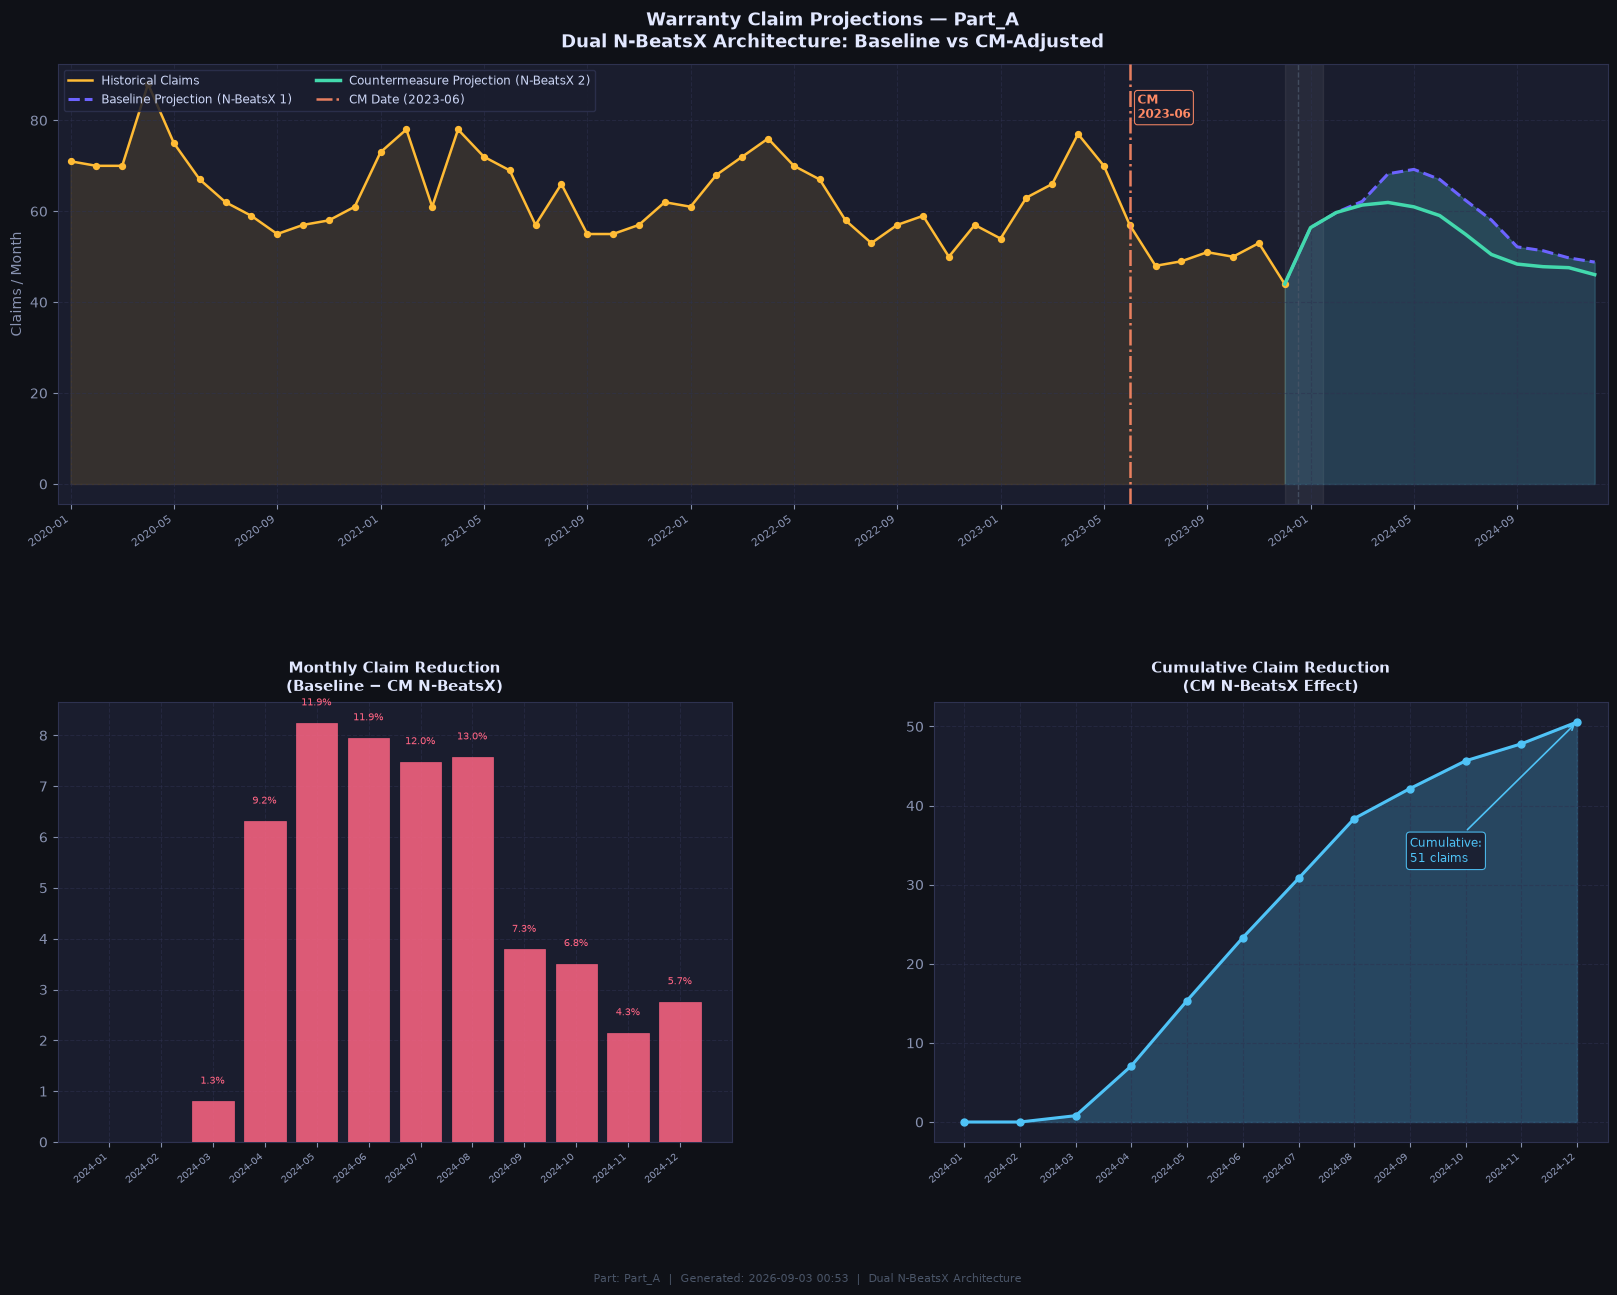

  ✅ Chart saved → .\nbeatsx_chart_projections.png


In [7]:
# ============================================================
# CELL 7 — Visualisation
# ============================================================

def _thin_ticks(labels, max_ticks=14):
    n = len(labels); step = max(1, n // max_ticks)
    idxs = list(range(0, n, step)); return idxs, [labels[i] for i in idxs]


def plot_projections(hist_periods, hist_claims, future_labels,
                     baseline_forecast, cm_forecast, cm_production,
                     comparison, cm_result, part_name,
                     countermeasure_taken, cm_date, model_name="N-BeatsX"):
    hist_labels = [str(p) for p in hist_periods]
    all_labels  = hist_labels + future_labels
    n_hist = len(hist_labels); n_fc = len(future_labels)
    fig = plt.figure(figsize=(20, 14), facecolor="#0F1117")
    gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)
    ax_main = fig.add_subplot(gs[0, :]); ax_bar = fig.add_subplot(gs[1, 0]); ax_cum = fig.add_subplot(gs[1, 1])
    TC = "#E2E8FF"; SC = "#8892B0"
    ax = ax_main
    ax.fill_between(range(n_hist), hist_claims, alpha=0.12, color=C_HIST)
    ax.plot(range(n_hist), hist_claims, color=C_HIST, lw=1.8, zorder=3, label="Historical Claims")
    ax.scatter(range(n_hist), hist_claims, color=C_HIST, s=18, zorder=4)
    ax.axvspan(n_hist-1, n_hist+0.5, alpha=0.06, color="white")
    ax.axvline(n_hist-0.5, color="#4A5568", ls="--", lw=1.0, alpha=0.8)
    fc_x = range(n_hist-1, n_hist+n_fc)
    fc_y_base = np.concatenate([[hist_claims[-1]], baseline_forecast])
    ax.fill_between(fc_x, fc_y_base, alpha=0.10, color=C_BASELINE)
    ax.plot(fc_x, fc_y_base, color=C_BASELINE, lw=2.2, ls="--", zorder=5,
            label=f"Baseline Projection ({model_name} 1)")
    if countermeasure_taken:
        fc_y_cm = np.concatenate([[hist_claims[-1]], cm_forecast])
        ax.fill_between(fc_x, fc_y_cm, alpha=0.15, color=C_CM)
        ax.plot(fc_x, fc_y_cm, color=C_CM, lw=2.5, zorder=6,
                label=f"Countermeasure Projection ({model_name} 2)")
        ax.fill_between(np.array(list(fc_x)), fc_y_base, fc_y_cm,
                        where=(fc_y_base >= fc_y_cm), alpha=0.20, color=C_CM,
                        interpolate=True, label="_nolegend_")
        if cm_date:
            try:
                cm_p = pd.Period(cm_date, freq="M")
                cm_idx = next((i for i, p in enumerate(hist_periods) if pd.Period(p, freq="M") == cm_p), None)
                if cm_idx is None:
                    cm_idx = next((n_hist+j for j, p in enumerate(future_labels) if pd.Period(p, freq="M") == cm_p), None)
                if cm_idx is not None:
                    ax.axvline(cm_idx, color=C_CM_LINE, lw=1.8, ls="-.", alpha=0.9, zorder=7,
                               label=f"CM Date ({cm_date})")
                    ax.text(cm_idx+0.3, ax.get_ylim()[1]*0.93, f"CM\n{cm_date}",
                            color=C_CM_LINE, fontsize=8.5, fontweight="bold", va="top", ha="left",
                            bbox=dict(fc="#1A1D2E", ec=C_CM_LINE, alpha=0.9, boxstyle="round,pad=0.25", lw=0.8))
            except: pass
    ax.set_title(f"Warranty Claim Projections — {part_name}\nDual {model_name} Architecture: Baseline vs CM-Adjusted",
                 color=TC, fontsize=13, fontweight="bold", pad=12)
    xi, xl = _thin_ticks(all_labels); ax.set_xticks(xi); ax.set_xticklabels(xl, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Claims / Month", color=SC); ax.legend(loc="upper left", fontsize=8.5, ncol=2)
    ax.set_xlim(-0.5, len(all_labels)-0.5)
    ax = ax_bar
    if countermeasure_taken:
        monthly_red = comparison["monthly_reduction"]; pct_red = comparison["pct_reduction"]
        x = np.arange(n_fc)
        bars = ax.bar(x, monthly_red, color=C_REDUCTION, alpha=0.85, edgecolor="#FF6584", lw=0.5, zorder=3)
        for bar, pct in zip(bars, pct_red):
            if bar.get_height() > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f"{pct:.1f}%",
                        ha="center", va="bottom", fontsize=7, color=C_REDUCTION)
        ax.set_title(f"Monthly Claim Reduction\n(Baseline − CM {model_name})", color=TC, fontsize=11, fontweight="bold", pad=8)
        ax.set_xticks(np.arange(n_fc)); ax.set_xticklabels(future_labels, rotation=40, ha="right", fontsize=7.5)
        ax.axhline(0, color="#4A5568", lw=0.8)
    else:
        ax.text(0.5, 0.5, "No Countermeasure\n(Baseline Only)", transform=ax.transAxes,
                ha="center", va="center", fontsize=13, color="#4A5568", style="italic")
        ax.set_title("Monthly Reduction", color=TC, fontsize=11, fontweight="bold", pad=8)
    ax = ax_cum
    if countermeasure_taken:
        cum_red = comparison["cumulative_reduction"]; x = np.arange(n_fc)
        ax.fill_between(x, cum_red, alpha=0.25, color=C_CUM)
        ax.plot(x, cum_red, color=C_CUM, lw=2.2, marker="o", markersize=5, zorder=4)
        ax.annotate(f"Cumulative:\n{cum_red[-1]:,.0f} claims", xy=(x[-1],cum_red[-1]),
                    xytext=(max(x[-1]-3,0),cum_red[-1]*0.65), fontsize=8.5, color=C_CUM,
                    arrowprops=dict(arrowstyle="->", color=C_CUM, lw=1.2),
                    bbox=dict(fc="#1A1D2E", ec=C_CUM, alpha=0.9, boxstyle="round,pad=0.3", lw=0.8))
        ax.set_title(f"Cumulative Claim Reduction\n(CM {model_name} Effect)", color=TC, fontsize=11, fontweight="bold", pad=8)
        ax.set_xticks(np.arange(n_fc)); ax.set_xticklabels(future_labels, rotation=40, ha="right", fontsize=7.5)
    else:
        ax.text(0.5, 0.5, "No Countermeasure\n(Baseline Only)", transform=ax.transAxes,
                ha="center", va="center", fontsize=13, color="#4A5568", style="italic")
        ax.set_title("Cumulative Reduction", color=TC, fontsize=11, fontweight="bold", pad=8)
    ts = datetime.now().strftime("%Y-%m-%d %H:%M")
    fig.text(0.5, 0.01, f"Part: {part_name}  |  Generated: {ts}  |  Dual {model_name} Architecture",
             ha="center", fontsize=8, color="#4A5568")
    return fig


fig_main = plot_projections(
    hist_periods=periods, hist_claims=claims_arr, future_labels=future_labels,
    baseline_forecast=baseline_forecast, cm_forecast=cm_forecast,
    cm_production=cm_production, comparison=comparison, cm_result=cm_result,
    part_name=selected_part, countermeasure_taken=COUNTERMEASURE_TAKEN,
    cm_date=COUNTERMEASURE_DATE if COUNTERMEASURE_TAKEN else None, model_name="N-BeatsX",
)
_chart_main_path = os.path.join(OUTPUT_DIR_NB, "nbeatsx_chart_projections.png")
fig_main.savefig(_chart_main_path, dpi=180, bbox_inches="tight", facecolor=fig_main.get_facecolor())
plt.show()
print(f"  ✅ Chart saved → {_chart_main_path}")


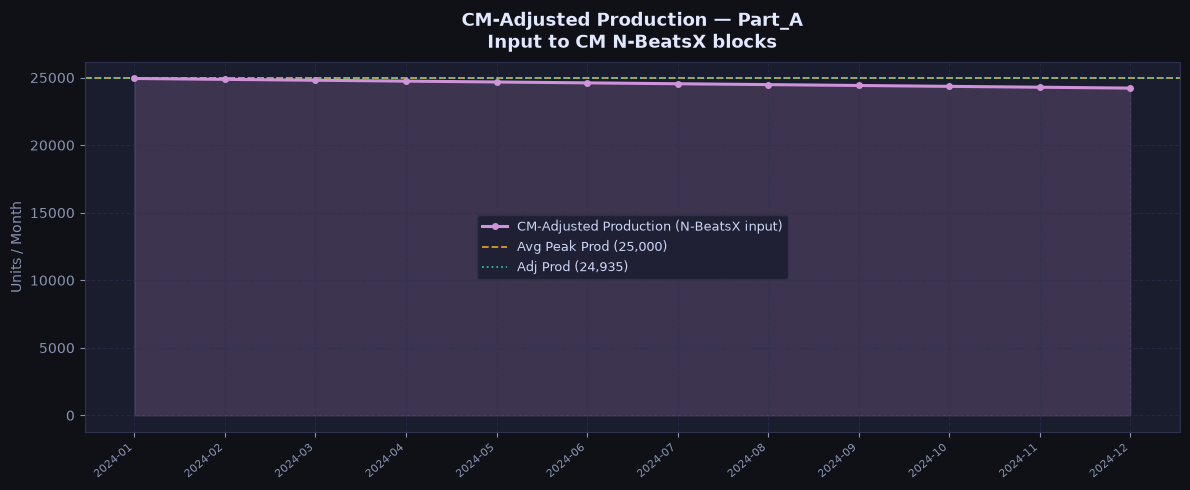

  ✅ Production chart saved → .\nbeatsx_chart_production.png


In [8]:
_chart_prod_path = None
if COUNTERMEASURE_TAKEN and cm_result["cm_active"]:
    fig, ax = plt.subplots(figsize=(12, 5), facecolor="#0F1117"); ax.set_facecolor("#1A1D2E")
    x = np.arange(len(future_labels)); cp = cm_result["cm_production"]
    ax.fill_between(x, cp, alpha=0.20, color=C_PROD)
    ax.plot(x, cp, color=C_PROD, lw=2.2, marker="o", markersize=4, zorder=4,
            label="CM-Adjusted Production (N-BeatsX input)")
    ax.axhline(cm_result["avg_peak_prod"], color="#FFBB35", lw=1.3, ls="--", alpha=0.8,
               label=f"Avg Peak Prod ({cm_result['avg_peak_prod']:,.0f})")
    ax.axhline(cm_result["adj_prod"], color="#43D9AD", lw=1.3, ls=":", alpha=0.8,
               label=f"Adj Prod ({cm_result['adj_prod']:,.0f})")
    ax.set_title(f"CM-Adjusted Production — {selected_part}\nInput to CM N-BeatsX blocks",
                 color="#E2E8FF", fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel("Units / Month", color="#8892B0")
    ax.set_xticks(x); ax.set_xticklabels(future_labels, rotation=40, ha="right", fontsize=8)
    ax.legend(fontsize=9); ax.grid(True, color="#2E3250", ls="--", alpha=0.5); fig.tight_layout()
    _chart_prod_path = os.path.join(OUTPUT_DIR_NB, "nbeatsx_chart_production.png")
    fig.savefig(_chart_prod_path, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor()); plt.show()
    print(f"  ✅ Production chart saved → {_chart_prod_path}")
else:
    print("  ℹ️  Production chart shown in CM mode only")


In [9]:
from IPython.display import display, HTML

def _kpi(label, value, unit="", color="#43D9AD"):
    return (f'<div style="display:inline-block;margin:8px;padding:16px 24px;'
            f'background:#1A1D2E;border:1px solid {color};border-radius:10px;'
            f'min-width:160px;text-align:center;">'
            f'<div style="color:#8892B0;font-size:11px;margin-bottom:6px;">{label}</div>'
            f'<div style="color:{color};font-size:22px;font-weight:bold;">{value}</div>'
            f'<div style="color:#4A5568;font-size:10px;">{unit}</div></div>')

kpi_html  = f'<div style="font-family:DejaVu Sans;"><h3 style="color:#CCD6F6;">📊 N-BeatsX Results — {selected_part}</h3>'
kpi_html += _kpi("Baseline Total", f"{baseline_forecast.sum():,.0f}", "claims", "#6C63FF")
if COUNTERMEASURE_TAKEN:
    kpi_html += _kpi("CM Total",f"{cm_forecast.sum():,.0f}","claims","#43D9AD")
    kpi_html += _kpi("Claims Saved",f"{comparison['total_reduction']:,.0f}","claims","#FF6584")
    kpi_html += _kpi("Reduction",f"{comparison['total_pct_reduction']:.1f}%","of baseline","#FFBB35")
    if comparison["total_cost_savings"]:
        kpi_html += _kpi("Cost Savings",f"${comparison['total_cost_savings']:,.0f}","estimated","#4FC3F7")
kpi_html += "</div>"
display(HTML(kpi_html))

comp_df = comparison["comparison_df"].copy()
for col in ["Baseline_Claims","CM_Claims","Monthly_Reduction","Cumulative_Reduction"]:
    comp_df[col] = comp_df[col].round(1)
comp_df["Reduction_%"] = comp_df["Reduction_%"].round(2)
if "Cost_Savings" in comp_df.columns: comp_df["Cost_Savings"] = comp_df["Cost_Savings"].round(0)
display(comp_df)
_tbl = os.path.join(OUTPUT_DIR_NB, "nbeatsx_comparison.csv")
comp_df.to_csv(_tbl, index=False)
print(f"  ✅ CSV saved → {_tbl}")


,Month,Baseline_Claims,CM_Claims,Monthly_Reduction,Cumulative_Reduction,Reduction_%,Cost_Savings
0,2024-01,56.4,56.4,0.0,0.0,0.00,0.0
1,2024-02,59.7,59.7,0.0,0.0,0.00,0.0
2,2024-03,62.2,61.4,0.8,0.8,1.29,681.0
3,2024-04,68.3,61.9,6.3,7.1,9.25,5365.0
4,2024-05,69.2,61.0,8.2,15.4,11.91,7008.0
5,2024-06,67.0,59.1,8.0,23.3,11.87,6758.0
6,2024-07,62.4,54.9,7.5,30.8,11.98,6359.0
7,2024-08,58.1,50.5,7.6,38.4,13.04,6438.0
8,2024-09,52.2,48.4,3.8,42.2,7.26,3220.0
9,2024-10,51.3,47.8,3.5,45.7,6.84,2982.0


  ✅ CSV saved → .\nbeatsx_comparison.csv


In [10]:
def build_pptx_report(part_name, baseline_forecast, cm_forecast, comparison, cm_result,
                       future_labels, hist_claims, chart_main_path, chart_prod_path,
                       countermeasure_taken, cm_date, output_path, model_name="N-BeatsX"):
    try:
        from pptx import Presentation
        from pptx.util import Inches, Pt
        from pptx.dml.color import RGBColor
        from pptx.enum.text import PP_ALIGN
    except ImportError:
        print("  ⚠️  pip install python-pptx"); return ""
    BG=RGBColor(0x0F,0x11,0x17); BG2=RGBColor(0x1A,0x1D,0x2E); WHITE=RGBColor(0xCC,0xD6,0xF6)
    GREY=RGBColor(0x88,0x92,0xB0); TEAL=RGBColor(0x43,0xD9,0xAD); PURP=RGBColor(0x6C,0x63,0xFF)
    ROSE=RGBColor(0xFF,0x65,0x84); AMBER=RGBColor(0xFF,0xBB,0x35); SKY=RGBColor(0x4F,0xC3,0xF7)
    def _bg(s,c=BG): f=s.background.fill; f.solid(); f.fore_color.rgb=c
    def _txt(s,text,l,t,w,h,sz=18,bold=False,color=WHITE,align=PP_ALIGN.LEFT,italic=False):
        tb=s.shapes.add_textbox(l,t,w,h); tf=tb.text_frame; tf.word_wrap=True
        p=tf.paragraphs[0]; p.alignment=align; r=p.add_run(); r.text=str(text)
        r.font.size=Pt(sz); r.font.bold=bold; r.font.italic=italic; r.font.color.rgb=color
    def _rect(s,l,t,w,h,rgb):
        sh=s.shapes.add_shape(1,l,t,w,h); sh.fill.solid(); sh.fill.fore_color.rgb=rgb; sh.line.fill.background()
    prs=Presentation(); prs.slide_width=Inches(13.33); prs.slide_height=Inches(7.5)
    blank=prs.slide_layouts[6]; ts=datetime.now().strftime("%Y-%m-%d %H:%M")
    accent=TEAL if countermeasure_taken else PURP
    s1=prs.slides.add_slide(blank); _bg(s1)
    _rect(s1,Inches(0),Inches(3.2),Inches(13.33),Inches(0.06),accent)
    _txt(s1,f"{model_name} Projection Report — Dual Architecture",Inches(1),Inches(1.5),Inches(11),Inches(1),sz=26,bold=True,color=WHITE,align=PP_ALIGN.CENTER)
    _txt(s1,f"Part: {part_name}",Inches(1),Inches(2.6),Inches(11),Inches(0.6),sz=18,color=accent,align=PP_ALIGN.CENTER)
    _txt(s1,f"Generated: {ts}",Inches(1),Inches(6.8),Inches(11),Inches(0.4),sz=9,color=GREY,align=PP_ALIGN.CENTER,italic=True)
    s2=prs.slides.add_slide(blank); _bg(s2)
    _txt(s2,"Executive Summary",Inches(0.5),Inches(0.3),Inches(12),Inches(0.6),sz=22,bold=True,color=WHITE)
    kpis=[("Horizon",f"{len(future_labels)} months",PURP),("History",f"{len(hist_claims)} months",AMBER),
          ("Baseline",f"{baseline_forecast.sum():,.0f} claims",PURP)]
    if countermeasure_taken:
        kpis+=[(f"CM Total",f"{cm_forecast.sum():,.0f}",TEAL),
               ("Saved",f"{comparison['total_reduction']:,.0f}",ROSE),
               ("Reduction",f"{comparison['total_pct_reduction']:.1f}%",AMBER)]
        if comparison["total_cost_savings"]: kpis.append(("Savings",f"${comparison['total_cost_savings']:,.0f}",SKY))
    for idx,(lbl,val,col) in enumerate(kpis):
        r,c=divmod(idx,4); bx=Inches(0.4+c*3.2); by=Inches(1.2+r*1.9)
        _rect(s2,bx,by,Inches(3.0),Inches(1.6),BG2); _rect(s2,bx,by,Inches(3.0),Inches(0.05),col)
        _txt(s2,lbl,bx+Inches(0.1),by+Inches(0.15),Inches(2.8),Inches(0.35),sz=9,color=GREY)
        _txt(s2,val,bx+Inches(0.1),by+Inches(0.6),Inches(2.8),Inches(0.7),sz=18,bold=True,color=col)
    s3=prs.slides.add_slide(blank); _bg(s3)
    _txt(s3,f"Projection Chart — Baseline vs CM {model_name}",Inches(0.3),Inches(0.15),Inches(12.5),Inches(0.5),sz=16,bold=True,color=WHITE)
    if os.path.exists(chart_main_path): s3.shapes.add_picture(chart_main_path,Inches(0.25),Inches(0.7),Inches(12.8),Inches(6.6))
    if countermeasure_taken and chart_prod_path and os.path.exists(chart_prod_path):
        s4=prs.slides.add_slide(blank); _bg(s4)
        _txt(s4,f"CM Production Trajectory (input to CM {model_name})",Inches(0.3),Inches(0.15),Inches(12.5),Inches(0.5),sz=16,bold=True,color=WHITE)
        s4.shapes.add_picture(chart_prod_path,Inches(0.4),Inches(0.75),Inches(12.5),Inches(6.2))
    s5=prs.slides.add_slide(blank); _bg(s5)
    _txt(s5,"Month-by-Month Comparison",Inches(0.3),Inches(0.15),Inches(12.5),Inches(0.5),sz=16,bold=True,color=WHITE)
    comp_df=comparison["comparison_df"]; cols=list(comp_df.columns); n_rows=len(comp_df)
    tbl=s5.shapes.add_table(n_rows+1,len(cols),Inches(0.2),Inches(0.75),Inches(12.9),Inches(min(6.5,0.38*(n_rows+1)))).table
    for c,col in enumerate(cols):
        cell=tbl.cell(0,c); cell.text=col; cell.fill.solid(); cell.fill.fore_color.rgb=RGBColor(0x12,0x14,0x22)
        p=cell.text_frame.paragraphs[0]; p.runs[0].font.size=Pt(8); p.runs[0].font.bold=True; p.runs[0].font.color.rgb=TEAL
    for r_,(_, row_d) in enumerate(comp_df.iterrows(), start=1):
        for c,col in enumerate(cols):
            cell=tbl.cell(r_,c); val=row_d[col]
            cell.text=f"{val:.1f}" if isinstance(val,float) else str(val)
            cell.fill.solid(); cell.fill.fore_color.rgb=BG2 if r_%2==0 else BG
            p=cell.text_frame.paragraphs[0]; p.runs[0].font.size=Pt(7.5); p.runs[0].font.color.rgb=WHITE
    prs.save(output_path); return output_path

if EXPORT_PPT:
    _ppt_path = os.path.join(OUTPUT_DIR_NB, f"nbeatsx_{selected_part.replace(' ','_')}_{datetime.now().strftime('%Y%m%d_%H%M')}.pptx")
    r = build_pptx_report(selected_part, baseline_forecast, cm_forecast, comparison, cm_result,
                          future_labels, claims_arr, _chart_main_path, _chart_prod_path,
                          COUNTERMEASURE_TAKEN, COUNTERMEASURE_DATE if COUNTERMEASURE_TAKEN else None,
                          _ppt_path, "N-BeatsX")
    if r: print(f"\n✅ PPT saved → {os.path.abspath(r)}")
else:
    print("  ℹ️  EXPORT_PPT = True to enable")

print(); print("=" * 60); print("  N-BEATS-X NOTEBOOK COMPLETE"); print("=" * 60)
print(f"  Part: {selected_part}  |  CM: {cm_result['cm_active']}")
print(f"  Baseline: {baseline_forecast.sum():,.0f}  CM: {cm_forecast.sum():,.0f}")
if cm_result["cm_active"]:
    print(f"  Reduction: {comparison['total_reduction']:,.0f} ({comparison['total_pct_reduction']:.1f}%)")
print("=" * 60)



✅ PPT saved → d:\forecasting_cursor_copy2\nbeatsx_Part_A_20260903_0053.pptx

  N-BEATS-X NOTEBOOK COMPLETE
  Part: Part_A  |  CM: True
  Baseline: 705  CM: 655
  Reduction: 51 (7.2%)


In [11]:
# ============================================================
# CELL 10 — Edge Case Testing
# ============================================================

def quick_test_nbeatsx(n_months=36, horizon=12, epochs=15, n_blocks=3):
    """Smoke test: fit BOTH N-BeatsX models on sine+noise series."""
    import warnings; warnings.filterwarnings("ignore")
    np.random.seed(42)
    t = np.arange(n_months)
    claims = np.clip(50 + 15*np.sin(2*np.pi*t/12) + np.random.normal(0, 4, n_months), 1, None)
    periods_t = [str(pd.Period("2021-01", freq="M") + i) for i in range(n_months)]
    prod_t    = np.full(n_months, 25_000.0)
    feat_df   = build_univariate_features(claims, periods_t, production=prod_t)
    feats_t   = feat_df[UNI_FEATURE_COLS].to_numpy(dtype=float)
    csc_t = MinMaxScaler(); esc_t = MinMaxScaler()
    ys_t  = csc_t.fit_transform(claims[:, None]).ravel()
    es_t  = esc_t.fit_transform(feats_t)
    W_t   = min(12, max(4, n_months // 3))
    H_t   = min(horizon, max(1, n_months - W_t - 1))
    X_t, Y_t = build_window_dataset(ys_t, es_t, W_t, H_t)
    if X_t is None: print("  Insufficient windows"); return
    n_exog_t = X_t.shape[-1] - 1
    last_win  = np.concatenate([ys_t[-W_t:,None], es_t[-W_t:]], axis=1)[None]

    print(f"  [Baseline N-BeatsX] {n_months}-month series, {n_blocks} blocks ...")
    m1 = NBeatsXForecaster(lookback=W_t, n_features=n_exog_t, horizon=H_t,
                            n_blocks=n_blocks, epochs=epochs, seed=42, early_patience=5)
    m1.fit(X_t, Y_t)
    fc1 = np.clip(csc_t.inverse_transform(np.clip(m1.predict(last_win)[0],0,1).reshape(-1,1)).ravel(), 0, None)

    avg_pc = claims.mean(); adj_p = max(prod_t.mean()-avg_pc, 1.0)
    cm_hp  = build_cm_adjusted_production(adj_p, avg_pc, n_months, WARRANTY_MONTHS)
    feats_cm = feats_t.copy(); feats_cm[:, UNI_FEATURE_COLS.index("Production_Vol")] = cm_hp
    esc_cm = MinMaxScaler(); es_cm = esc_cm.fit_transform(feats_cm)
    X_cm, Y_cm = build_window_dataset(ys_t, es_cm, W_t, H_t)
    last_win_cm = np.concatenate([ys_t[-W_t:,None], es_cm[-W_t:]], axis=1)[None]
    rw = np.maximum(0.0, 1.0 - np.arange(H_t, dtype=float) / float(WARRANTY_MONTHS))
    cm_physics = avg_pc * rw

    print(f"  [CM N-BeatsX]       {n_months}-month series, {n_blocks} blocks ...")
    n_exog_cm = X_cm.shape[-1] - 1
    m2 = NBeatsXForecaster(lookback=W_t, n_features=n_exog_cm, horizon=H_t,
                            n_blocks=n_blocks, epochs=epochs, seed=43, early_patience=5, dropout=0.05)
    m2.fit(X_cm, Y_cm)
    fc2_raw = np.clip(csc_t.inverse_transform(np.clip(m2.predict(last_win_cm)[0],0,1).reshape(-1,1)).ravel(), 0, None)
    fc2 = np.clip(0.70*cm_physics + 0.30*np.minimum(fc2_raw, fc1), 0.0, fc1)

    print()
    print(f"  Baseline  : {np.round(fc1, 1)}")
    print(f"  CM        : {np.round(fc2, 1)}")
    print(f"  Reduction : {np.round(fc1-fc2, 1)}")
    print(f"  CM ≤ Baseline: {bool(np.all(fc2 <= fc1 + 1e-6))}")
    return fc1, fc2


print("=" * 55)
print("  N-BEATS-X EDGE CASE TESTS")
print("=" * 55)
print("\n[ Test 1: 36-month series, 3 blocks ]")
_ = quick_test_nbeatsx(n_months=36, n_blocks=3, epochs=15)
print("\n[ Test 2: 48-month series, 4 blocks ]")
_ = quick_test_nbeatsx(n_months=48, n_blocks=4, epochs=15)
print()
print("✅ Edge case tests complete")


  N-BEATS-X EDGE CASE TESTS

[ Test 1: 36-month series, 3 blocks ]
  [Baseline N-BeatsX] 36-month series, 3 blocks ...


N-BeatsX epochs: 100%|██████████| 15/15 [00:06<00:00,  2.38ep/s, loss=0.0643]


  [CM N-BeatsX]       36-month series, 3 blocks ...


N-BeatsX epochs: 100%|██████████| 15/15 [00:05<00:00,  2.68ep/s, loss=0.0644]



  Baseline  : [48.4 49.6 50.1 50.7 50.3 49.5 48.6 48.6 48.6 47.9 48.2 48.8]
  CM        : [48.4 48.5 47.6 46.9 45.8 44.6 43.4 42.4 41.4 40.3 39.4 38.6]
  Reduction : [ 0.   1.1  2.5  3.8  4.5  4.9  5.3  6.2  7.1  7.6  8.8 10.1]
  CM ≤ Baseline: True

[ Test 2: 48-month series, 4 blocks ]
  [Baseline N-BeatsX] 48-month series, 4 blocks ...


N-BeatsX epochs: 100%|██████████| 15/15 [00:13<00:00,  1.14ep/s, loss=0.0425]


  [CM N-BeatsX]       48-month series, 4 blocks ...


N-BeatsX epochs: 100%|██████████| 15/15 [00:14<00:00,  1.07ep/s, loss=0.0392]


  Baseline  : [46.3 49.2 52.9 55.2 57.4 56.3 54.1 50.2 47.3 43.2 41.8 43.3]
  CM        : [46.3 48.2 48.4 48.1 47.7 46.1 44.1 41.9 40.5 38.5 37.4 36.9]
  Reduction : [ 0.   0.9  4.5  7.1  9.7 10.2  9.9  8.3  6.8  4.7  4.4  6.4]
  CM ≤ Baseline: True

✅ Edge case tests complete
